#Data Overview


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#It is the initial step to load the python dictionaries.


In [ ]:
import pandas as pd
df = pd.read_csv('/content/austo_automobile .csv', encoding='unicode_escape')

#It helps to load the dataset to work on it.

In [ ]:
df.info()
#It shows the presence of different data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1528 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1475 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory usage: 173.1+ KB


In [ ]:
df.isnull().sum()
#It helps to find any null values in the data set that need to be treated or removed.


,0
Age,0
Gender,53
Profession,0
Marital_status,0
Education,0
No_of_Dependents,0
Personal_loan,0
House_loan,0
Partner_working,0
Salary,0


Gender and Partner_salary columns have missing values, which need to be addressed before further analysis.

In [ ]:
df.head()

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,53,Male,Business,Married,Post Graduate,4,No,No,Yes,99300,70700.0,170000,61000,SUV
1,53,Femal,Salaried,Married,Post Graduate,4,Yes,No,Yes,95500,70300.0,165800,61000,SUV
2,53,Female,Salaried,Married,Post Graduate,3,No,No,Yes,97300,60700.0,158000,57000,SUV
3,53,Female,Salaried,Married,Graduate,2,Yes,No,Yes,72500,70300.0,142800,61000,SUV
4,53,Male,Salaried,Married,Post Graduate,3,No,No,Yes,79700,60200.0,139900,57000,SUV


In [ ]:
df.tail()

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
1576,22,Male,Salaried,Single,Graduate,2,No,Yes,No,33300,0.0,33300,27000,Hatchback
1577,22,Male,Business,Married,Graduate,4,No,No,No,32000,NaN,32000,31000,Hatchback
1578,22,Male,Business,Single,Graduate,2,No,Yes,No,32900,0.0,32900,30000,Hatchback
1579,22,Male,Business,Married,Graduate,3,Yes,Yes,No,32200,NaN,32200,24000,Hatchback
1580,22,Male,Salaried,Married,Graduate,4,No,No,No,31600,0.0,31600,31000,Hatchback


In [ ]:
df.shape
#It helps to find the number of rows and columns in a dataset.

(1581, 14)

We have 1581 rows and 14 columns

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1581.0,31.922201,8.425978,22.0,25.0,29.0,38.0,54.0
No_of_Dependents,1581.0,2.457938,0.943483,0.0,2.0,2.0,3.0,4.0
Salary,1581.0,60392.220114,14674.825044,30000.0,51900.0,59500.0,71800.0,99300.0
Partner_salary,1475.0,20225.559322,19573.149277,0.0,0.0,25600.0,38300.0,80500.0
Total_salary,1581.0,79625.996205,25545.857768,30000.0,60500.0,78000.0,95900.0,171000.0
Price,1581.0,35597.722960,13633.636545,18000.0,25000.0,31000.0,47000.0,70000.0


#Observations

- It can be observed that the maximum total salary is 171000.

- Maximum no of dependents are 4 while minimum is 0.

- Average price of cars id 35598 and the maximum price is 70000 which is exactly the double of mean.

- Most of the buyers age between 29 to 31.

#Data Level discrepencies

- Gender Column has some wrong inputs.

- Gender Column has missing values.

- Partner_salary Column has missing values.



In [ ]:
df['Gender'].unique()
#It helps to find all the unique values in the particular column.
#Observation: We have 4 different types of values in Gender.

array(['Male', 'Femal', 'Female', nan, 'Femle'], dtype=object)

In [ ]:
df['Gender'].value_counts()
#It helps to find the total no of each type of elements in a dataset.

,count
Gender,
Male,1199
Female,327
Femal,1
Femle,1



- We have 1199 Males, 327 Females.
- Few error values -'femal' and 'femle' also exist which need to be treated


In [ ]:
df.fillna({'Gender': df['Gender'].mode()[0]}, inplace=True)
#It helps to fill in the missing values in the gender column using mode method.



#Action
- Here we are using mode since the percentage of missing values is very less and using mode will not
affect the overall results.

In [ ]:
df['Gender'] = df['Gender'].replace('Femle', 'Female')
df['Gender'] = df['Gender'].replace('Femal', 'Female')
#It helps to replace the existing value with a new value or the correct value.

In [ ]:
df['Gender'].value_counts()

,count
Gender,
Male,1252
Female,329


In [ ]:
df.isnull().sum()


,0
Age,0
Gender,0
Profession,0
Marital_status,0
Education,0
No_of_Dependents,0
Personal_loan,0
House_loan,0
Partner_working,0
Salary,0


# Result
- We have treated the missing and wrong values for 'Gender' column.

In [ ]:
df['Partner_salary'].value_counts()
#It helps to find the total no of each type of values in a dataset.

,count
Partner_salary,
0.0,623
40500.0,29
40200.0,27
40000.0,25
40100.0,25
...,...
300.0,1
22300.0,1
500.0,1


- We have 623 rows with partner's salary as 0.

In [ ]:
df['Partner_salary'].isnull().sum()


np.int64(90)

In [ ]:
df.loc[(df['Partner_working'] == 'No') & (df['Partner_salary'].isnull()),
    'Partner_salary'] = 0


In [ ]:
df.loc[
    (df['Partner_working'] == 'Yes') & (df['Partner_salary'].isnull()),
    'Partner_salary'] = df['Total_salary'] - df['Salary']


In [ ]:
df.isnull().sum()
#It helps to find any null values in the data set that need to be treated or removed.

,0
Age,0
Gender,0
Profession,0
Marital_status,0
Education,0
No_of_Dependents,0
Personal_loan,0
House_loan,0
Partner_working,0
Salary,0


#Observation

- We have identified the cells with partner working as Yes and No and on that basis calculated the
Partner's salary. If partner working is 'No' then the salary will be 0 but if partner is working and we
have a null value in Partners salary then we have calculated it by using formula: Total salary=
Partner salary + salary

In [ ]:
df.nunique()

,0
Age,33
Gender,2
Profession,2
Marital_status,2
Education,2
No_of_Dependents,5
Personal_loan,2
House_loan,2
Partner_working,2
Salary,538


In [ ]:
df.head()

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,53,Male,Business,Married,Post Graduate,4,No,No,Yes,99300,70700.0,170000,61000,SUV
1,53,Female,Salaried,Married,Post Graduate,4,Yes,No,Yes,95500,70300.0,165800,61000,SUV
2,53,Female,Salaried,Married,Post Graduate,3,No,No,Yes,97300,60700.0,158000,57000,SUV
3,53,Female,Salaried,Married,Graduate,2,Yes,No,Yes,72500,70300.0,142800,61000,SUV
4,53,Male,Salaried,Married,Post Graduate,3,No,No,Yes,79700,60200.0,139900,57000,SUV


#Observations

- There were some discrepencies in Gender & Partner Salary Column.
- We have treated the missing values and spelling mistakes.
- We have ensured there are no null values left in data. For better analysis.

#Insight

- It seems like there were some entry level mistakes while data entry. (Fmale/femal). Which can be managed through standardized data entry.




##Univariate Analysis


In [ ]:
# Define the bins for age groups
bins = [20, 30, 40, 50,60, float('inf')]
labels = ['20-30', '30-40', '40-50', '50-60','>60']

# Create a new column 'Age_group' based on the age bins
df['Age_group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

df.head(2)

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make,Age_group
0,53,Male,Business,Married,Post Graduate,4,No,No,Yes,99300,70700.0,170000,61000,SUV,50-60
1,53,Femal,Salaried,Married,Post Graduate,4,Yes,No,Yes,95500,70300.0,165800,61000,SUV,50-60


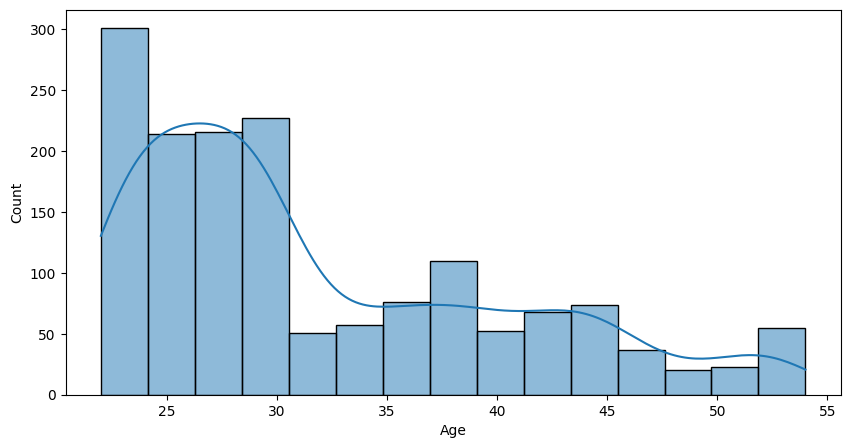

In [ ]:
import matplotlib.pyplot as plt
# Age histplot
plt.figure(figsize=(10,5))
sns.histplot(data= df, x= "Age", kde= True);

Here can conclude that most individuals are below the  age of 25.

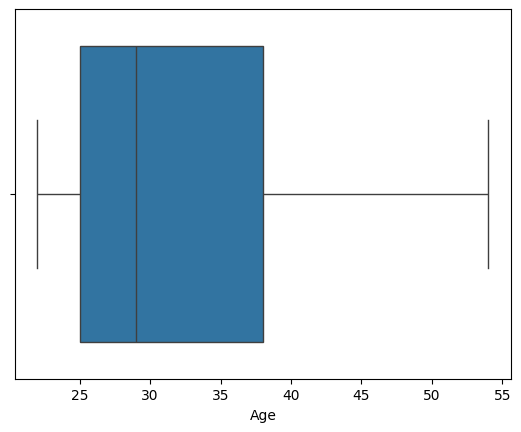

In [ ]:
sns.boxplot(data = df, x = 'Age');

**Observations on Age**
- There are no outliers present in the data.
- The distribution displays a right-skewed pattern.
- The median age is approximately 29 years, with the maximum age reaching around 54 years.

##Salary Uni-Analysis

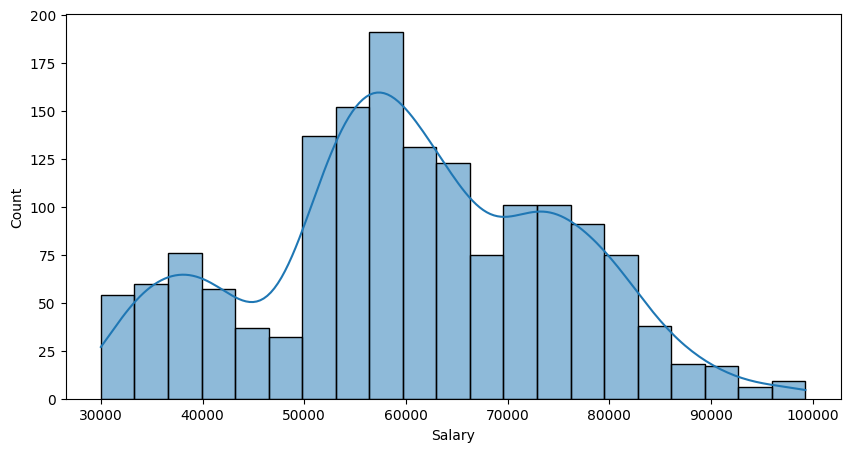

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data= df, x= "Salary", kde= True);

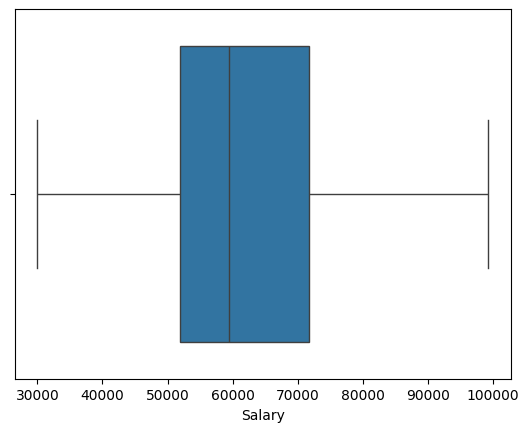

In [ ]:
sns.boxplot(data = df, x = 'Salary');

**Salary observations**
- There are no outliers detected, and the distribution does not conform to a normal pattern.
- The median individual salary is approximately INR 59,500, with the maximum salary recorded at INR 93,300.

##Partner_salary Uni-Analysis

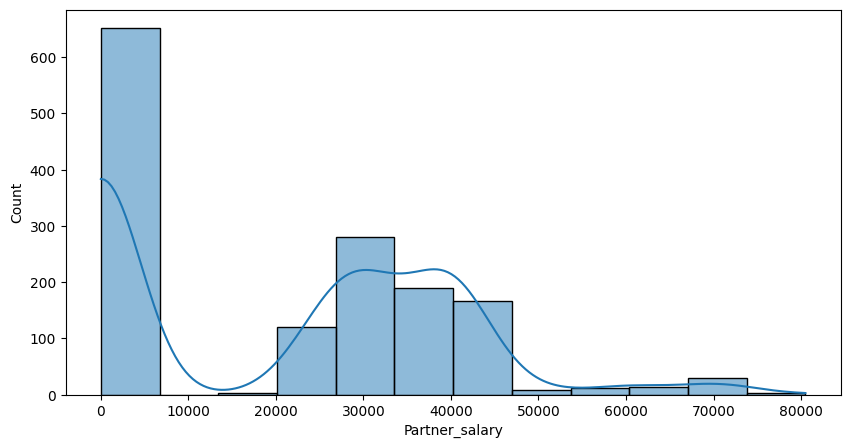

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data= df, x= "Partner_salary", kde= True);

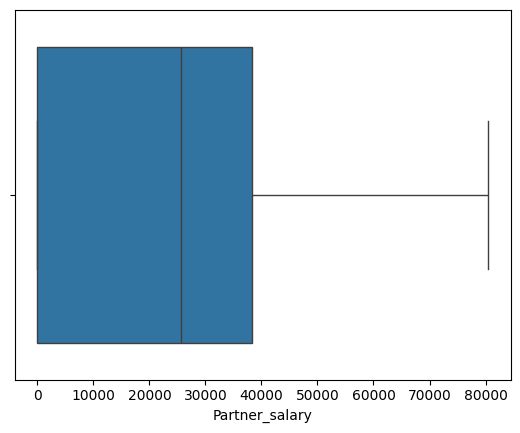

In [ ]:
sns.boxplot(data = df, x = 'Partner_salary');

In [ ]:
## let's try to understand the partner_saslary more than 65000
df.loc[df['Partner_salary']>71000]

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make,Age_group
56,51,Female,Salaried,Married,Post Graduate,2,No,No,Yes,90600,80400.0,171000,69000,SUV,50-60
116,47,Male,Business,Married,Graduate,4,Yes,No,Yes,86000,80500.0,166500,69000,SUV,40-50


**Observations on partner's salary**
- It appears that the total salary is influenced by both partner salary and individual salary, necessitating further analysis.
- Moreover, the distribution exhibits a right-skewed pattern, indicating asymmetry towards higher salary values.

## Total_salary Uni-Analysis

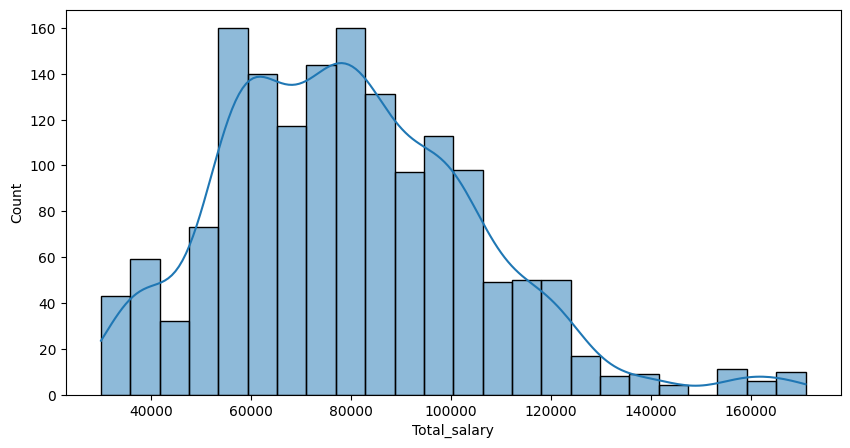

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data= df, x= "Total_salary", kde= True);

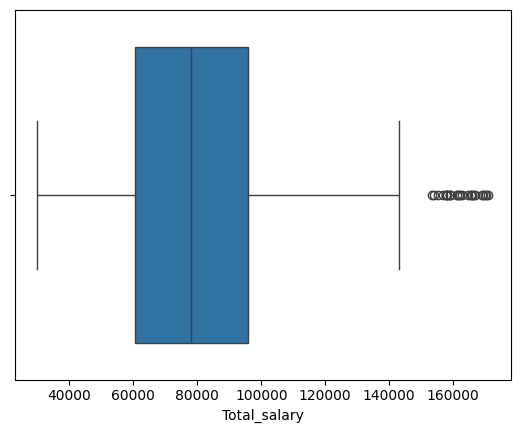

In [ ]:
sns.boxplot(data = df, x = 'Total_salary');

- There are few outliers on Total_salary

In [ ]:
df.loc[df['Total_salary']>145000]

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make,Age_group
0,53,Male,Business,Married,Post Graduate,4,No,No,Yes,99300,70700.0,170000,61000,SUV,50-60
1,53,Femal,Salaried,Married,Post Graduate,4,Yes,No,Yes,95500,70300.0,165800,61000,SUV,50-60
2,53,Female,Salaried,Married,Post Graduate,3,No,No,Yes,97300,60700.0,158000,57000,SUV,50-60
17,49,Female,Salaried,Married,Post Graduate,4,No,No,Yes,95100,70600.0,165700,64000,SUV,40-50
18,49,Female,Business,Married,Post Graduate,3,No,No,Yes,92600,70300.0,162900,58000,SUV,40-50
19,49,Male,Salaried,Married,Post Graduate,3,Yes,No,Yes,98400,60600.0,159000,54000,SUV,40-50
29,46,Female,Salaried,Married,Post Graduate,2,No,No,Yes,98300,70700.0,169000,61000,SUV,40-50
30,46,Male,Salaried,Married,Post Graduate,4,No,No,Yes,94900,70700.0,165600,67000,SUV,40-50
31,46,Male,Business,Married,Graduate,2,Yes,No,Yes,91100,70000.0,161100,66000,SUV,40-50
41,53,Female,Salaried,Married,Post Graduate,4,No,No,Yes,96600,70300.0,166900,66000,SUV,50-60


In [ ]:
df.loc[df['Total_salary']>145000].shape

(27, 15)

**Observation on Total Salary**
- It's evident that outliers are present in the total salary column, likely stemming from high individual and partner salaries.

## Price Uni-Analysis

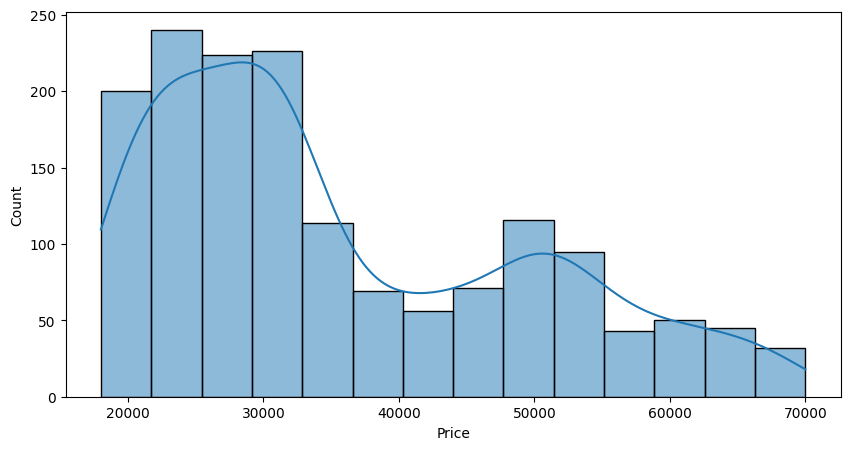

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data= df, x= "Price", kde= True);

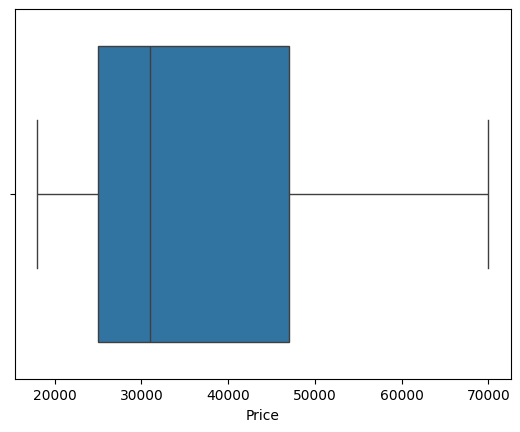

In [ ]:
sns.boxplot(data = df, x = 'Price');

**Observation on Price**
- The distribution is skewed to the right and exhibits a bimodal pattern.

#Bivariate Analysis
let's understand how the numerical variables are associated with each other

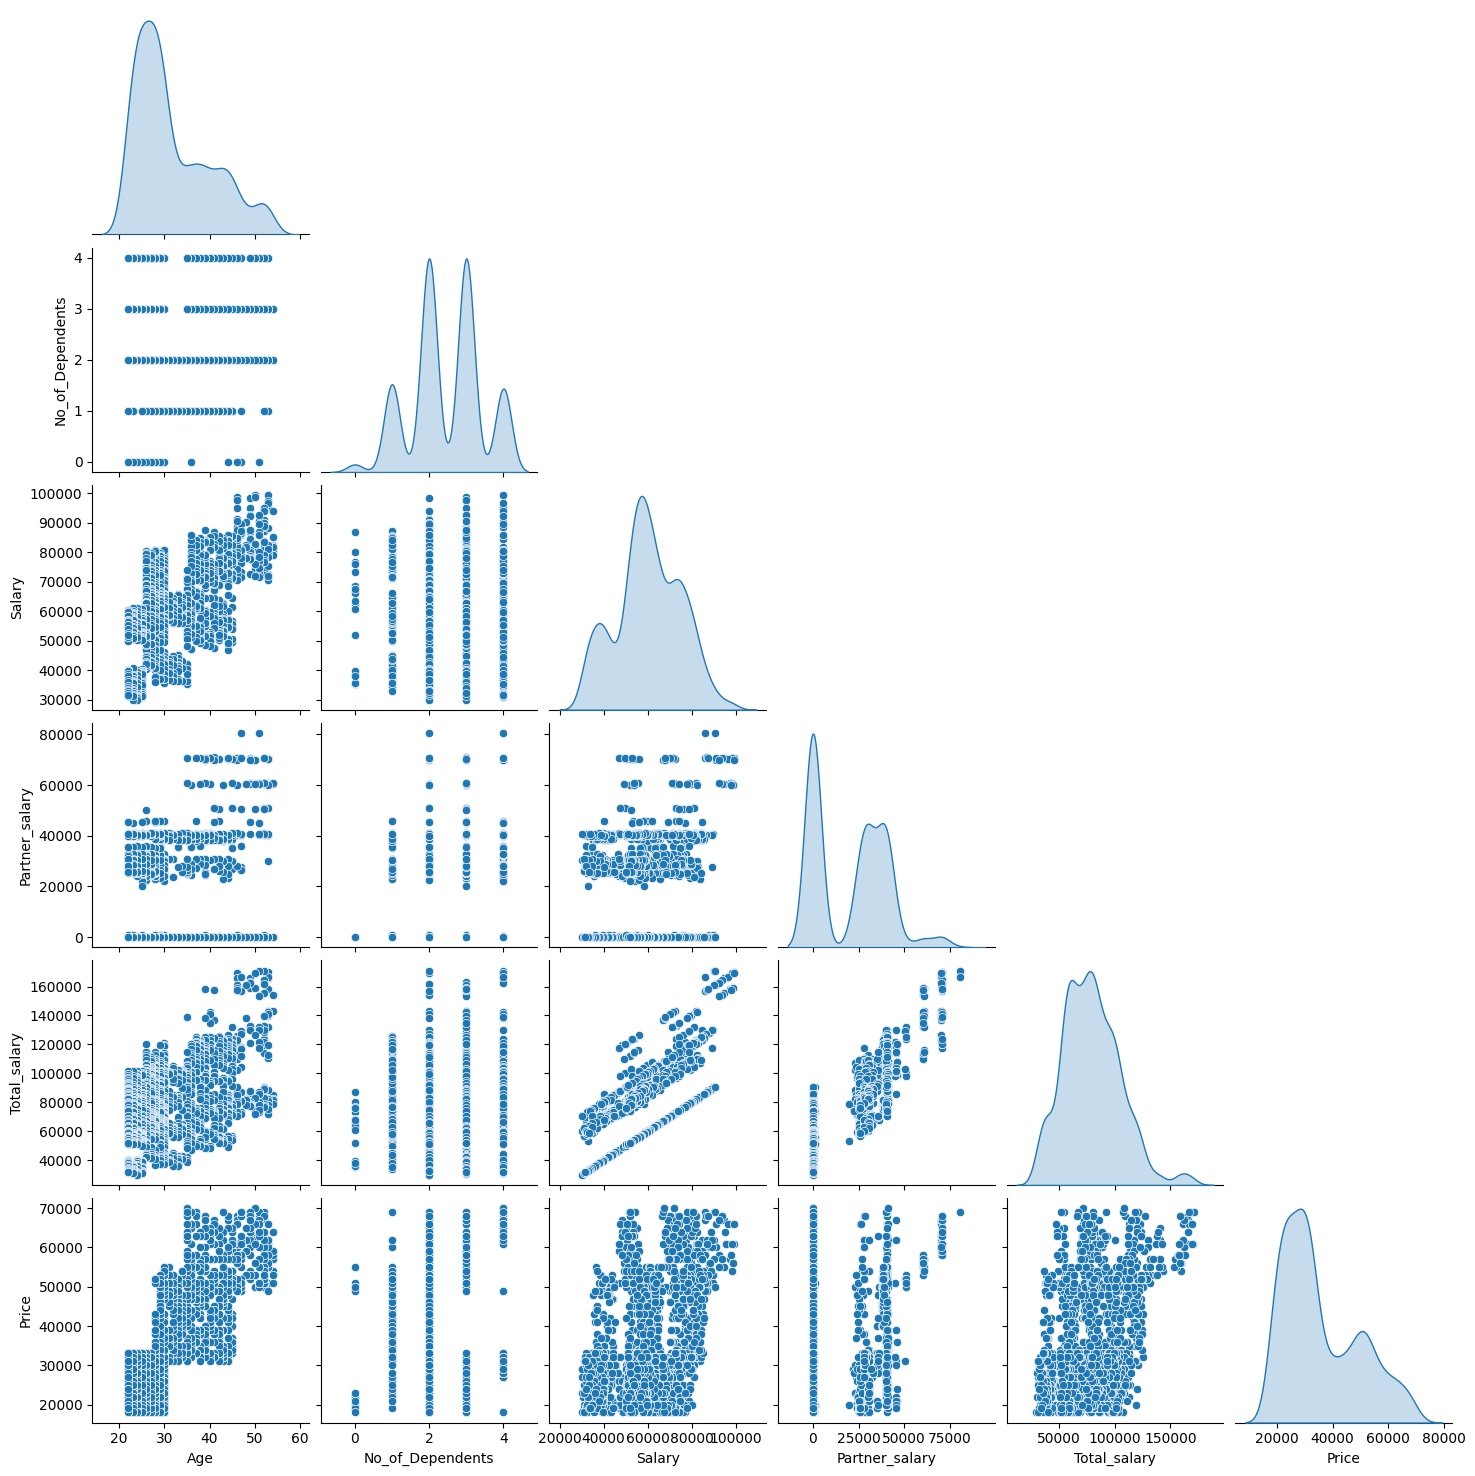

In [ ]:
sns.pairplot(df, diag_kind="kde",corner=True);

In [ ]:
correlation = df.corr(numeric_only = True)
correlation

,Age,No_of_Dependents,Salary,Partner_salary,Total_salary,Price
Age,1.000000,-0.189614,0.616899,0.126267,0.458869,0.797831
No_of_Dependents,-0.189614,1.000000,-0.031746,0.131253,0.092890,-0.135839
Salary,0.616899,-0.031746,1.000000,0.071049,0.641560,0.409920
Partner_salary,0.126267,0.131253,0.071049,1.000000,0.813945,0.167725
Total_salary,0.458869,0.092890,0.641560,0.813945,1.000000,0.367823
Price,0.797831,-0.135839,0.409920,0.167725,0.367823,1.000000


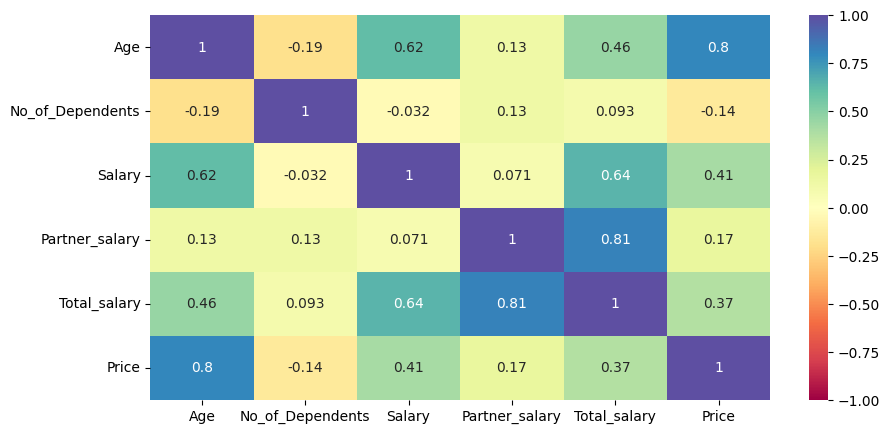

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only = True),
            annot=True, cmap='Spectral', vmin =-1, vmax=1)
# vmin corelation starts from this point ends at vmax
plt.show()

- We can observe positive correlations between Price and Age, Partner salary and Total salary, as well as individual salary and total salary.
- However, partner's salary appears to have a stronger influence on the total salary.
- Additionally, there seems to be an inverse relationship between the number of dependents and age.

**Let us check if how different genders plays a role in buying cars**

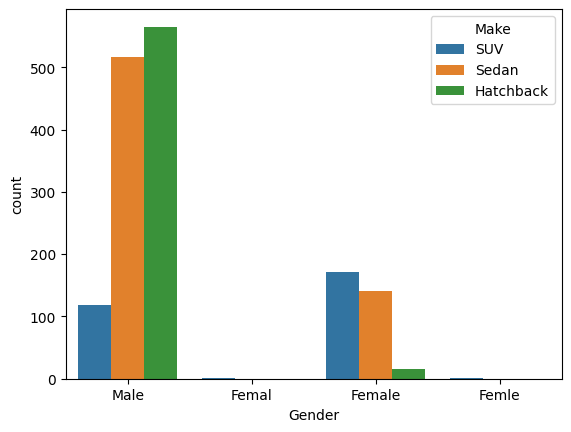

In [ ]:
#Do men tend to prefer SUVs more compared to women?
sns.countplot(df,x='Gender',hue='Make');

- Male individuals generally exhibit a higher preference for **hatchback** cars, followed by **sedans**, while female individuals tend to favor **SUVs**, followed by **sedans**.



**Let's check how profession plays an important role in buying cars**

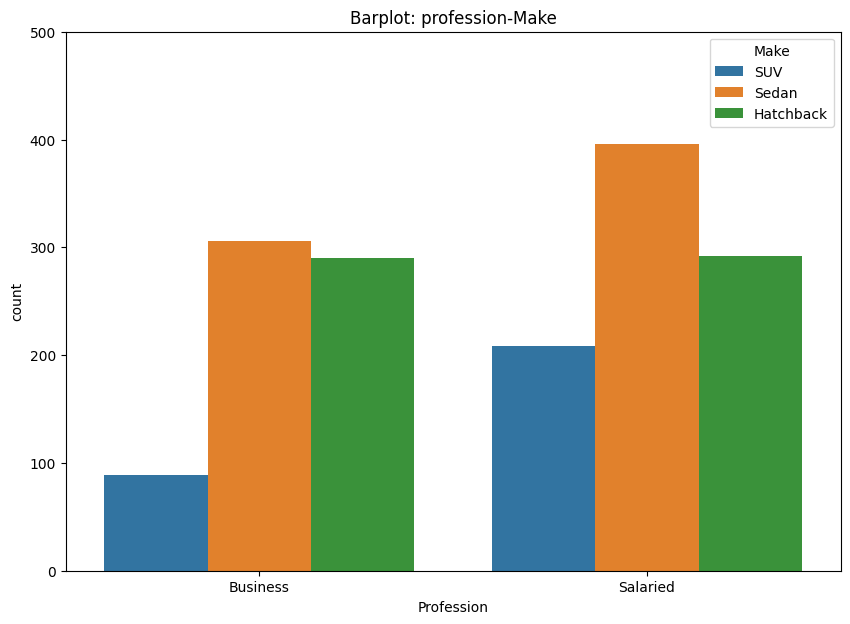

In [ ]:
plt.figure(figsize=(10,7))
plt.title('Barplot: profession-Make')
plt.ylim(0,500)

ax=sns.countplot(df,x='Profession',hue='Make');

In [ ]:
# counting the total number of salaried individuals who bought a sedan
salaried_sedan_counts= df[(df['Profession']=='Salaried') & (df['Make']=='Sedan')].shape[0]

# total salaried individuals
Total_salaried_counts= df[df['Profession']=='Salaried'].shape[0]

# calculating likelyhood
likelihood=(salaried_sedan_counts/Total_salaried_counts)*100
print('Likelihood of a salaried individual buying a Sedan: ', likelihood ,'%')

Likelihood of a salaried individual buying a Sedan:  44.19642857142857 %


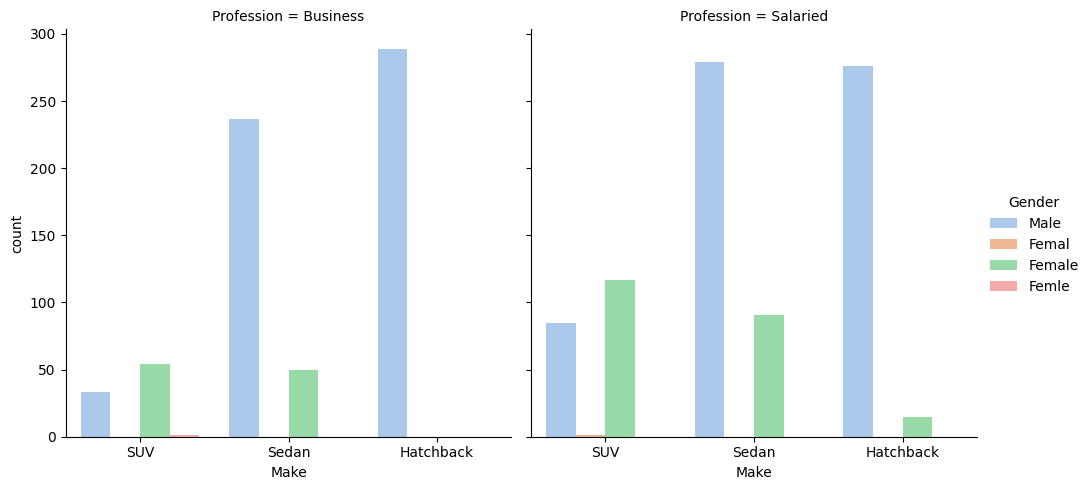

In [ ]:
## What evidence or data supports Sheldon Cooper's claim that a salaried male is an easier target for a SUV sale over a Sedan sale?
sns.catplot(df,col='Profession',x='Make',hue='Gender',kind='count',palette='pastel');

- Male individuals who are salaried tend to show a higher interest in purchasing **sedan** cars rather than SUVs.

**Let's try to analyze the amount spend on purchasing based on the genders**

In [ ]:
## use goupby for gender and mean of price
df.groupby('Gender')['Price'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
Femal,1.0,61000.000000,NaN,61000.0,61000.0,61000.0,61000.0,61000.0
Female,327.0,47611.620795,11213.991567,20000.0,38000.0,49000.0,55000.0,69000.0
Femle,1.0,65000.000000,NaN,65000.0,65000.0,65000.0,65000.0,65000.0
Male,1199.0,32817.347790,12299.239195,18000.0,24000.0,29000.0,37500.0,70000.0


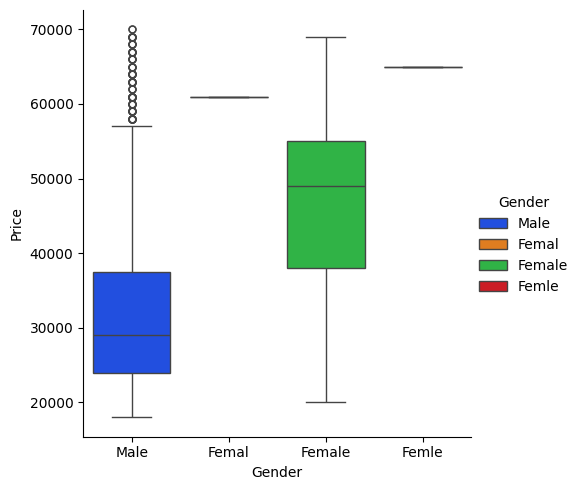

In [ ]:
sns.catplot(data=df, x="Gender", y="Price", hue="Gender", kind='box', palette='bright');

- Females tend to have a higher potential for purchasing automobiles or exhibit a tendency to spend more on them compared to males.
- Approximately 75% of male purchases are within 37,000 INR, while for females, more than 75% of purchases start at 38,000 INR and above.
- Additionally, outliers have been observed in male purchasing expenditures.

**Let's try to understand why women's purchasing habit is more significant**
- Previously, we noted that the majority of females are inclined towards purchasing SUVs, followed by sedans.

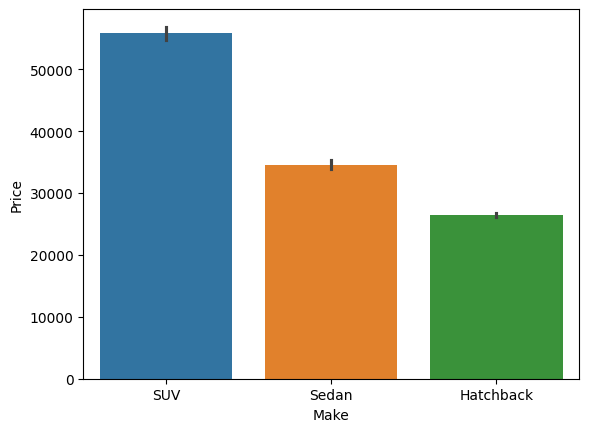

In [ ]:
# lets check the price structure for different types of Make

sns.barplot(df,x='Make',y='Price',hue='Make');

- it's clear that SUV and Sedan cars has more price structure.

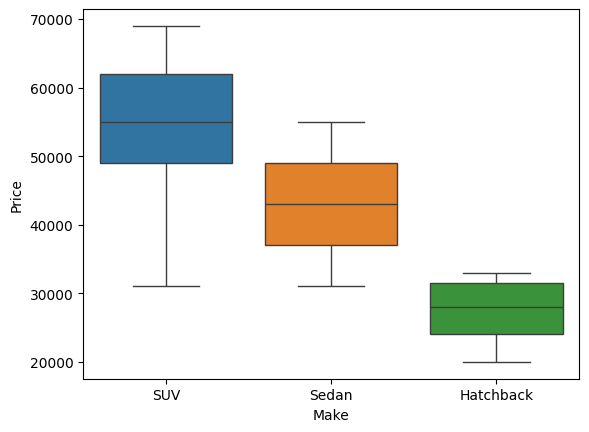

In [ ]:
## Let's create a data frame for Female
df_womens = df.loc[df['Gender']=='Female']

## let's try to analyze the price structure where Females are focusing
sns.boxplot(data=df_womens, x='Make',y='Price',hue='Make');

In [ ]:
df_womens.groupby('Make')['Price'].describe()

,count,mean,std,min,25%,50%,75%,max
Make,,,,,,,,
Hatchback,15.0,27466.666667,4240.395310,20000.0,24000.0,28000.0,31500.0,33000.0
SUV,171.0,53368.421053,10384.884228,31000.0,49000.0,55000.0,62000.0,69000.0
Sedan,141.0,42773.049645,7248.023173,31000.0,37000.0,43000.0,49000.0,55000.0


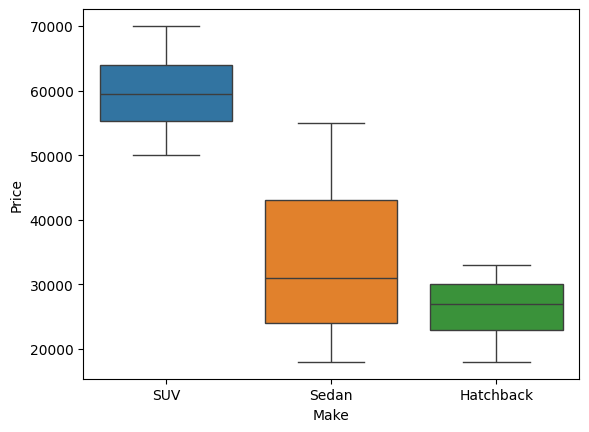

In [ ]:
#Let's try to understand the male pattern
df_males = df.loc[df['Gender']=='Male']
sns.boxplot(data=df_males, x='Make',y='Price',hue='Make');

In [ ]:
df_males.groupby('Make')['Price'].describe()

,count,mean,std,min,25%,50%,75%,max
Make,,,,,,,,
Hatchback,565.0,26476.106195,4273.646655,18000.0,23000.0,27000.0,30000.0,33000.0
SUV,118.0,59584.745763,5673.941441,50000.0,55250.0,59500.0,64000.0,70000.0
Sedan,516.0,33639.534884,10752.371921,18000.0,24000.0,31000.0,43000.0,55000.0


**Observation on female purchase**
- Male buyers demonstrate a preference for hatchback cars, but they also purchase sedans at a similar rate. Notably, they tend to opt for lower-priced sedan models, with a mean price of INR 32550.80.

- In contrast, female buyers show a higher inclination towards purchasing SUVs, which typically have higher prices. They also show interest in higher-priced sedan models, with mean prices of INR 53,479 for SUVs and INR 42,773 for sedans.

**Let's try to understand the effect of age group on price**

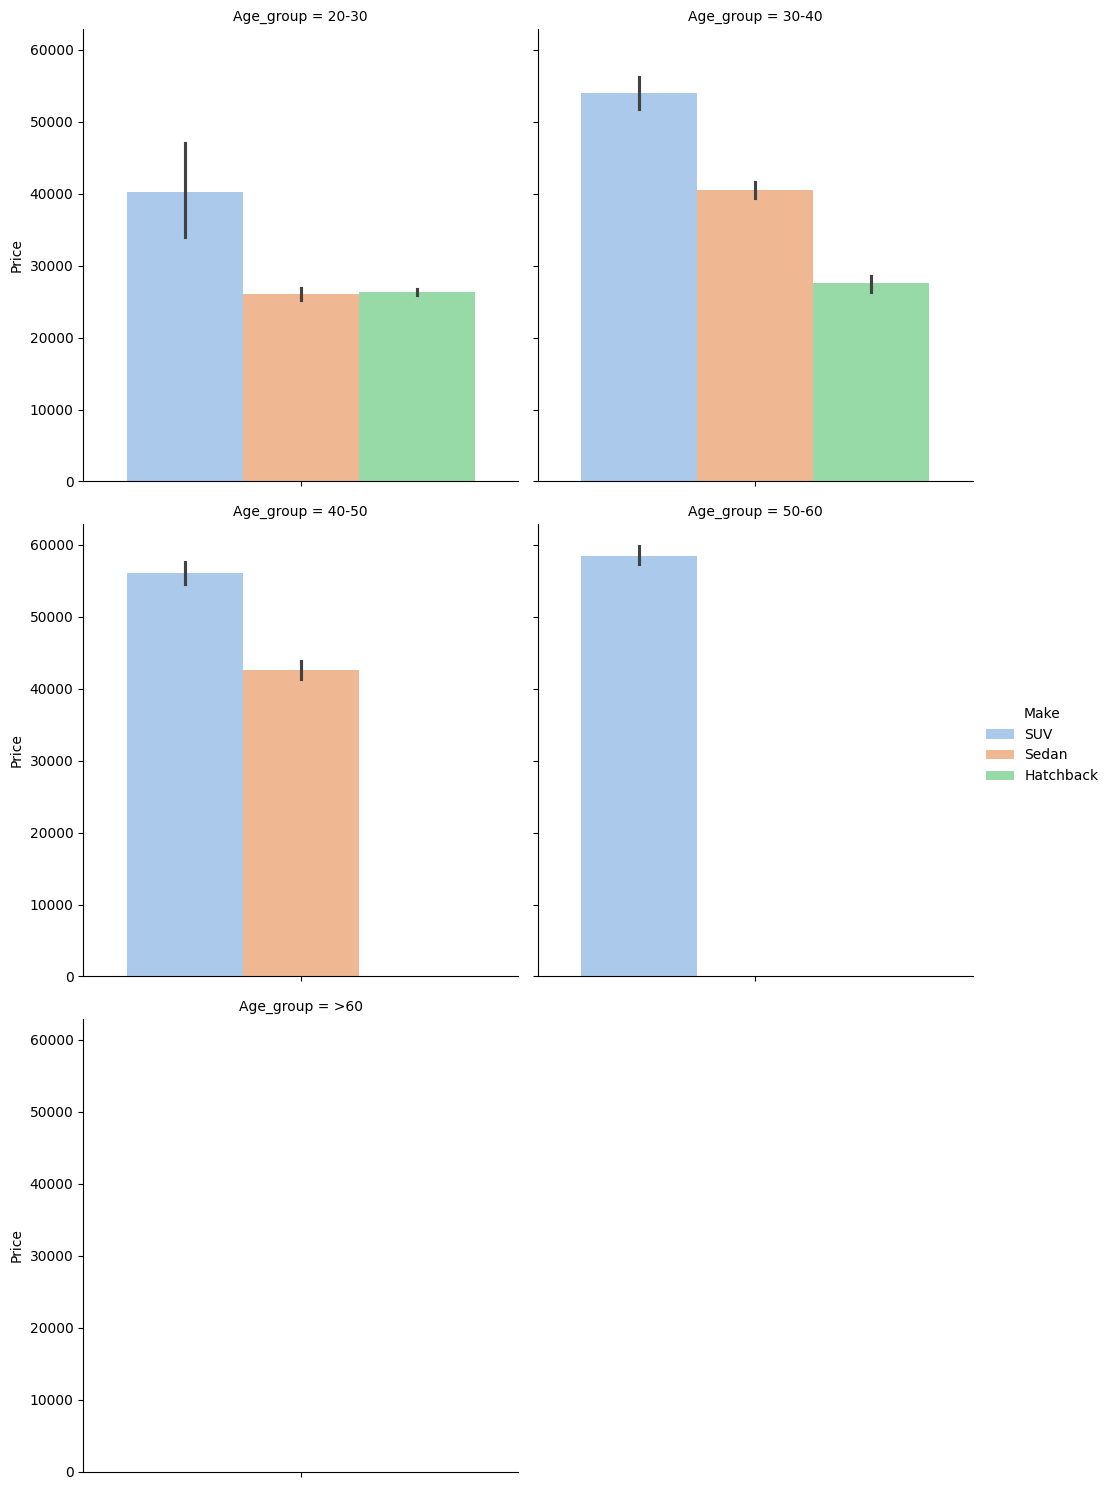

In [ ]:
# Define the bins for age groups
bins = [20, 30, 40, 50,60, float('inf')]
labels = ['20-30', '30-40', '40-50', '50-60','>60']

# Create a new column 'Age_group' based on the age bins
df['Age_group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
sns.catplot(df,col='Age_group',y='Price',hue='Make',kind='bar',col_wrap=2,palette='pastel');

/tmp/ipython-input-2824231727.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.lineplot(df,x='Age_group',y='Price',ci= False);


(0.0, 80000.0)

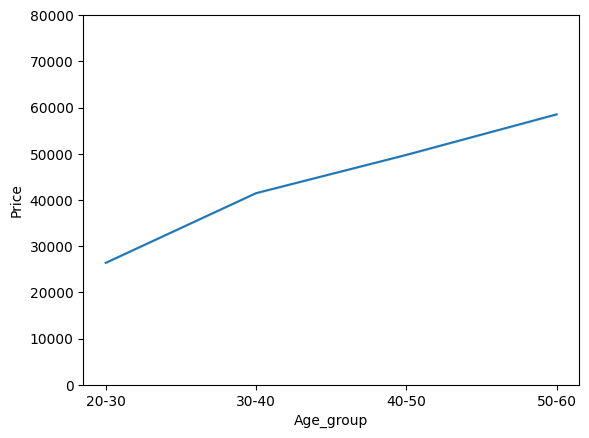

In [ ]:
sns.lineplot(df,x='Age_group',y='Price',ci= False);
plt.ylim(0,80000)

/tmp/ipython-input-1998793333.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df, x="Age_group", y="Price", kind='box', palette='bright');


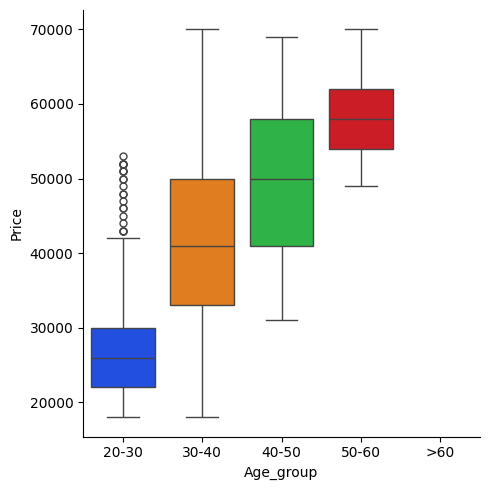

In [ ]:
sns.catplot(data=df, x="Age_group", y="Price", kind='box', palette='bright');

- As individuals grow older, they tend to have fewer dependents and allocate more spending towards higher-priced vehicles.

**Let's try to understand the effect of personal loan on price**

In [ ]:
## How much money was spent on purchasing automobiles by individuals who took a personal loan?
df.groupby('Personal_loan')['Price'].describe()

,count,mean,std,min,25%,50%,75%,max
Personal_loan,,,,,,,,
No,789.0,36742.712294,14534.344526,18000.0,25000.0,32000.0,49000.0,70000.0
Yes,792.0,34457.070707,12578.780338,18000.0,24000.0,31000.0,45000.0,70000.0


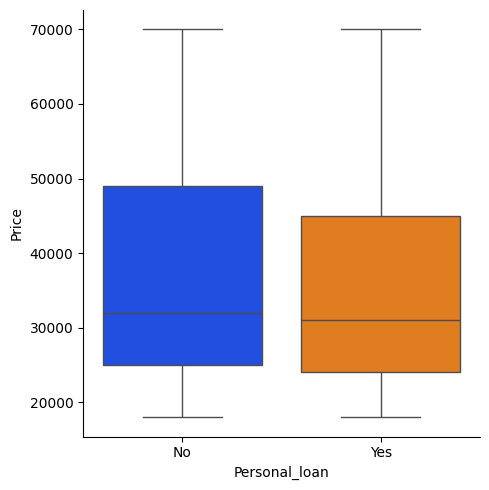

In [ ]:
sns.catplot(data=df, x="Personal_loan", y="Price", hue="Personal_loan", kind='box', palette='bright');

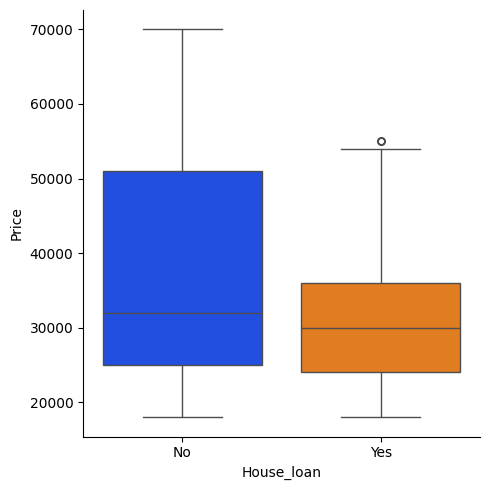

In [ ]:
sns.catplot(data=df, x="House_loan", y="Price", hue="House_loan", kind='box', palette='bright');

In [ ]:
df.groupby('House_loan')['Price'].describe()

,count,mean,std,min,25%,50%,75%,max
House_loan,,,,,,,,
No,1054.0,37707.779886,14816.702037,18000.0,25000.0,32000.0,51000.0,70000.0
Yes,527.0,31377.609108,9596.008338,18000.0,24000.0,30000.0,36000.0,55000.0


- For individuals who have taken a personal loan, about 75% of their purchases fall below INR 45,000, with a median purchase amount ranging between INR 31,000 and INR 32,000.
- Interestingly, there doesn't seem to be a significant difference in purchasing limits between those who have taken a personal loan and those who haven't.
- Nevertheless, there exists a significant correlation between having a house loan and one's purchasing behavior. Individuals with house loans tend to opt for cars with lower prices. Approximately 75% of individuals with house loans have bought cars priced at INR 36,000, with a mean purchase value of INR 313,777.609, considerably lower compared to those without loans.

**Let's check if there are any involvement of working partner on purchase of higher price cars**

In [ ]:
# How does having a working partner influence the purchase of higher-priced cars?
df.groupby('Partner_working')['Price'].describe()


,count,mean,std,min,25%,50%,75%,max
Partner_working,,,,,,,,
No,713.0,36000.000000,13817.734086,18000.0,25000.0,31000.0,48000.0,70000.0
Yes,868.0,35267.281106,13479.532555,18000.0,24000.0,31000.0,46000.0,70000.0


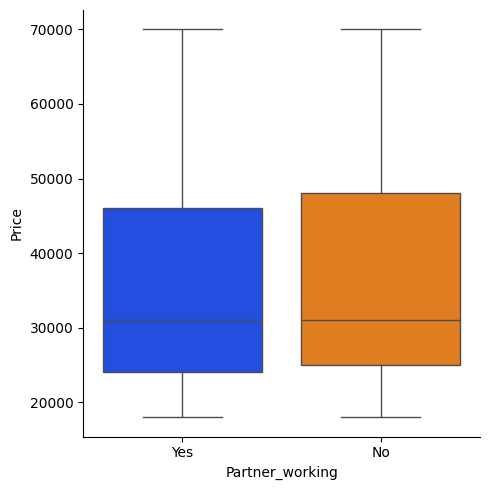

In [ ]:
sns.catplot(data=df, x="Partner_working", y="Price", hue="Partner_working", kind='box', palette='bright');

- There isn't a noticeable distinction to highlight. It appears that whether the partner is employed or not, the buying tendencies appear to be similar.

**Conclusions**
- Men showed a preference for Hatchback cars followed by Sedans, women tend to prefer SUVs followed by Sedans.
- Among salaried individuals, around 44.19% have opted for Sedan cars. Similarly, approximately 44.67% of business owners have chosen Sedan cars.
- Females tend to spend more on purchasing automobiles compared to males.
- Observed the uphill trend i.e. as the individual grow old they tend to allocate more spending towards higher-priced vehicles.
- For those with personal loans, around 75% of purchases are under INR 45,000, with a median purchase of INR 31,000 to INR 32,000. Surprisingly, the purchasing limits show little variation between loan holders and non-holders.
- There isn't a significant observable difference in purchasing tendencies based on whether the partner is working or not.




**Business Recommendations**
- Since men prefer Hatchback cars and women prefer SUVs, Austo Automobiles could consider expanding their product line to include more SUV models targeted towards female customers. This could help tap into a segment of the market with high potential for sales growth.
- Recognizing that females tend to spend more on purchasing automobiles, Austo Automobiles should develop marketing campaigns specifically targeting female customers. This could include advertisements highlighting features that appeal to female preferences and creating a welcoming and inclusive buying experience at dealerships.
- Since older individuals tend to allocate more spending towards higher-priced vehicles, Austo Automobiles could introduce premium or luxury car models aimed at this demographic. These vehicles could feature advanced technology, comfort, and safety features that appeal to older customers.
- Since there isn't a significant observable difference in purchasing tendencies based on whether the partner is working or not, Austo Automobiles should prioritize delivering an exceptional customer experience to all customers. This includes providing excellent pre-sales and after-sales service, offering test drives, and ensuring a seamless buying process.


